In [9]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import numpy as np
import matplotlib.pyplot as plt
import h5py
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
from jax import random
import optax
import diffrax
import equinox as eqx

from triangular_transport.flows.flow_trainer import NNTrainer
from triangular_transport.flows.interpolants import linear_interpolant, linear_interpolant_der
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.flows.methods.utils import UnitGaussianNormalizer
from triangular_transport.flows.dataloaders import gaussian_reference_sampler

from darcy_unet import FlatDarcyUNet

## Config
Adjust `N_TRAIN` and the UNet knobs here, then run all cells.

In [42]:
# ── data ──────────────────────────────────────────────────────────────────────
N_TRAIN  = 50_000   # number of training samples (max ~100_000)

# NSAMPLES: number of posterior samples to generate at test time.
# conditional_sample vmaps the UNet over all NSAMPLES at every ODE solver step
# (Dopri5 takes ~20–50 adaptive steps), so memory cost is NSAMPLES × n_ode_steps.
# 5_000 is enough for SWD and visualisation; 40_000 matches h-MALA but OOMs.
NSAMPLES = 5_000

EPOCHS   = 650

# ── UNet architecture ─────────────────────────────────────────────────────────
BASE_CH        = 4    # 48 → ~938k params; 32 → ~417k (faster for quick tests)
COND_EMBED_DIM = 32
ENC_HIDDEN     = 128
T_EMBED_DIM    = 8
T_MLP_HIDDEN   = 96

# ── optimiser ─────────────────────────────────────────────────────────────────
PEAK_LR      = 2e-3
WEIGHT_DECAY = 2e-4
CLIP_NORM    = 5.0

# ── training ──────────────────────────────────────────────────────────────────
# Rule of thumb for this GPU:
#   BATCH_SIZE=1024  →  ~5.7 GB activations  (fast, recommended)
#   BATCH_SIZE=2048  →  ~11.5 GB             (try if 1024 is still slow)
#   BATCH_SIZE=256   →  ~1.4 GB  (safe but GPU is underutilised → slow)
BATCH_SIZE = 1024

NX = NY = 33
FLAT_LENGTH = NX * NY   # 1089

## SWD helper

In [34]:
def sliced_wasserstein_jax(x, y, n_projections=512, seed=42, chunk_size=64, p=2):
    n_x, d = x.shape
    n_y    = y.shape[0]
    assert n_projections % chunk_size == 0
    t_x = (jnp.arange(n_x, dtype=jnp.float32) + 0.5) / n_x
    t_y = (jnp.arange(n_y, dtype=jnp.float32) + 0.5) / n_y
    t   = jnp.sort(jnp.concatenate([t_x, t_y]))

    @jax.jit
    def chunk_cost(key):
        theta = jax.random.normal(key, (chunk_size, d))
        theta = theta / jnp.linalg.norm(theta, axis=1, keepdims=True)
        xp = jnp.sort(x @ theta.T, axis=0).T
        yp = jnp.sort(y @ theta.T, axis=0).T
        def one_cost(xi, yi):
            return jnp.mean((jnp.interp(t, t_x, xi) - jnp.interp(t, t_y, yi)) ** p)
        return jnp.mean(jax.vmap(one_cost)(xp, yp))

    keys = jax.random.split(jax.random.PRNGKey(seed), n_projections // chunk_size)
    cost = jnp.mean(jnp.array([chunk_cost(k) for k in keys]))
    return float(cost ** (1.0 / p))

## Load h-MALA reference chains

In [12]:
RESHAPE_NO  = 200_000;  THIN_FACTOR     = 10;  CHAIN_ITERS     = 2
AUX_RESHAPE = 200_000;  AUX_THIN_FACTOR = 10;  AUX_CHAIN_ITERS = 2
COND_LABELS = ["obs", "med", "98"]

def load_chains(folder, reshape_no, thin, n_iters):
    chains = []
    for i in tqdm(range(n_iters), desc=folder):
        path  = os.path.join(folder, f"chain_{i:03d}", "hmala_samples.npz")
        chain = np.load(path)["arr"].reshape(reshape_no, FLAT_LENGTH)
        chains.append(chain[::thin])
    return np.vstack(chains)

hmala_obs = load_chains("mcmc_main_ref", RESHAPE_NO,  THIN_FACTOR,     CHAIN_ITERS)
hmala_med = load_chains("mcmc_med_ref",  AUX_RESHAPE, AUX_THIN_FACTOR, AUX_CHAIN_ITERS)
hmala_98  = load_chains("mcmc_98_ref",   AUX_RESHAPE, AUX_THIN_FACTOR, AUX_CHAIN_ITERS)
hmala_list = [hmala_obs, hmala_med, hmala_98]

for label, h in zip(COND_LABELS, hmala_list):
    print(f"h-MALA ({label}): {h.shape}")

mcmc_main_ref:   0%|          | 0/2 [00:00<?, ?it/s]

mcmc_med_ref:   0%|          | 0/2 [00:00<?, ?it/s]

mcmc_98_ref:   0%|          | 0/2 [00:00<?, ?it/s]

h-MALA (obs): (40000, 1089)
h-MALA (med): (40000, 1089)
h-MALA (98): (40000, 1089)


## Load training data + normalise y

In [35]:
def read_data_h5(path="data.h5"):
    with h5py.File(path, "r") as f:
        return f["/target"][...], f["/data"][...]

TOTAL_DIM = 100_000

ys_all = np.load("training_dataset/solutions_grid_noise.npy")
us_all = np.load("training_dataset/parameters_noise.npy").reshape(-1, FLAT_LENGTH)

ys     = ys_all[:TOTAL_DIM]
us     = us_all[:TOTAL_DIM]
us_ref = us_all[TOTAL_DIM : TOTAL_DIM * 2].copy()
np.random.shuffle(us_ref)
us_test = us_all[TOTAL_DIM * 2 :].copy()

# Observation data and normaliser (same as MLP baseline)
_, yobs     = read_data_h5()
yobs        = np.load("data_obs.npy")
yobs_med    = np.load("data_50.npy")
yobs_98     = np.load("data_98.npy")

ys_normalizer = UnitGaussianNormalizer(ys)
ys_norm       = ys_normalizer.encode()
yobs_norm     = ys_normalizer.encode(yobs)
ymed_norm     = ys_normalizer.encode(yobs_med)
y98_norm      = ys_normalizer.encode(yobs_98)
ncond_vals    = [yobs_norm, ymed_norm, y98_norm]

Y_DIM = ys_norm.shape[1]   # 100
U_DIM = FLAT_LENGTH        # 1089
print(f"y_dim={Y_DIM}  u_dim={U_DIM}")

y_dim=100  u_dim=1089


## Normalise u field
Global mean + std from the reference split centres the field and gives unit
overall variance, making the reference distribution approximately N(0, 1).
This replaces the whitened PCA used in the MLP baseline.

In [36]:
u_mean = float(us_ref.mean())
u_std  = float(us_ref.std())
print(f"u field  mean={u_mean:.4f}  std={u_std:.4f}")

def normalise_u(u):   return (u - u_mean) / u_std
def denormalise_u(u): return u * u_std + u_mean

us_norm      = normalise_u(us[:N_TRAIN])
us_ref_norm  = normalise_u(us_ref[:N_TRAIN])
us_test_norm = normalise_u(us_test)

u field  mean=-0.0001  std=0.0958


## Build joint arrays and model

In [43]:
# x1 = [y_norm, u_norm]      — target  (joint samples from p(y, u))
# x0 = [y_norm, u_ref_norm]  — reference (same y, independent prior u)
x1_data = np.hstack([np.asarray(ys_norm[:N_TRAIN]), us_norm])
x0_data = np.hstack([np.asarray(ys_norm[:N_TRAIN]), us_ref_norm])

yu_dimension     = (Y_DIM, U_DIM)
interpolant_args = {"t": None, "x1": None, "x0": None}

# ODE initial conditions: normalised prior samples from the test split
u0_cond = jnp.asarray(us_test_norm[:NSAMPLES])

solver_args = {
    "solver":              diffrax.Dopri5(),
    "max_steps":           50_000,
    "stepsize_controller": diffrax.PIDController(rtol=1e-4, atol=1e-6),
}

key = random.PRNGKey(42)
key, model_key = random.split(key)

model = FlatDarcyUNet(
    y_dim=Y_DIM,
    u_dim=U_DIM,
    true_hw=NX,
    base_ch=BASE_CH,
    cond_embed_dim=COND_EMBED_DIM,
    enc_hidden=ENC_HIDDEN,
    t_embed_dim=T_EMBED_DIM,
    t_mlp_hidden=T_MLP_HIDDEN,
    key=model_key,
)

n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
print(f"UNet parameters: {n_params:,}")

batch_size      = min(BATCH_SIZE, N_TRAIN - 1)
steps_per_epoch = int(np.ceil(N_TRAIN / batch_size))
steps           = steps_per_epoch * EPOCHS
print(f"N_TRAIN={N_TRAIN}  batch_size={batch_size}  steps={steps:,}")

schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=PEAK_LR,
    warmup_steps=max(50, steps // 20),
    decay_steps=steps,
    end_value=1e-4,
)
optimizer = optax.chain(
    optax.clip_by_global_norm(CLIP_NORM),
    optax.adamw(schedule, weight_decay=WEIGHT_DECAY),
)

UNet parameters: 39,297
N_TRAIN=50000  batch_size=1024  steps=31,850


## Train

In [44]:
trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=linear_interpolant,
    interpolant_der=linear_interpolant_der,
    reference_sampler=gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
    reference_sampler_args={"mu": jnp.zeros(U_DIM), "sigma": 1.0, "normalizer": None},
)

trainer.train(
    train_data=x1_data,
    train_dim=N_TRAIN,
    batch_size=batch_size,
    steps=steps,
    x0_data=x0_data,
    print_every=10_000,
);

Training neural network


  0%|          | 0/31850 [00:00<?, ?it/s]

W0428 18:32:39.728987 1057013 conv_rewriter.cc:549] Fusing this pattern to backward convolution would cause negative padding (-2) on right/bottom of the activations, which is not supported by GpuConvPaddingLegalization (b/32744257). Falling back to unfused convolution for instruction: %conv_general_dilated.48 = f32[1024,4,36,36]{3,2,1,0} convolution(%broadcast_in_dim.98, %rev.0), window={size=3x3 pad=1_4x1_4}, dim_labels=bf01_io01->bf01, metadata={op_name="jit(make_step)/transpose(jvp(jit(vec_field_loss)))/vmap(eqx.nn.Conv)/conv_general_dilated" source_file="/home/verano13/TransportVsMcmcExperiments_fix/poisson/darcy_unet.py" source_line=236 source_end_line=236 source_column=14 source_end_column=30}


step = 0, train_loss = 124.34552764892578
step = 10000, train_loss = -1393.795166015625
step = 20000, train_loss = -1389.890625
step = 30000, train_loss = -1500.9775390625
step = 31849, train_loss = -1449.58740234375


## Generate posterior samples

In [46]:
cond_samples_list = trainer.conditional_sample(
    cond_values=ncond_vals,
    u0_cond=u0_cond[:NSAMPLES],
    nsamples=NSAMPLES,
    solver_args=solver_args,
)

# Denormalise: extract u from [y, u] output, undo global normalisation
u_flat_list, u_grid_list = [], []
for label, samps in zip(COND_LABELS, cond_samples_list):
    u_norm_gen = np.array(samps[:, Y_DIM:])        # (NSAMPLES, 1089)
    u_flat     = denormalise_u(u_norm_gen)          # back to field space
    u_flat_list.append(u_flat)
    u_grid_list.append(u_flat.reshape(NSAMPLES, NX, NY))
    print(f"[{label}] u_flat range: [{u_flat.min():.3f}, {u_flat.max():.3f}]")

  0%|          | 0/3 [00:00<?, ?it/s]

[obs] u_flat range: [-0.341, 0.389]
[med] u_flat range: [-0.330, 0.426]
[98] u_flat range: [-0.392, 0.300]


## Posterior mean and variance — all three conditions

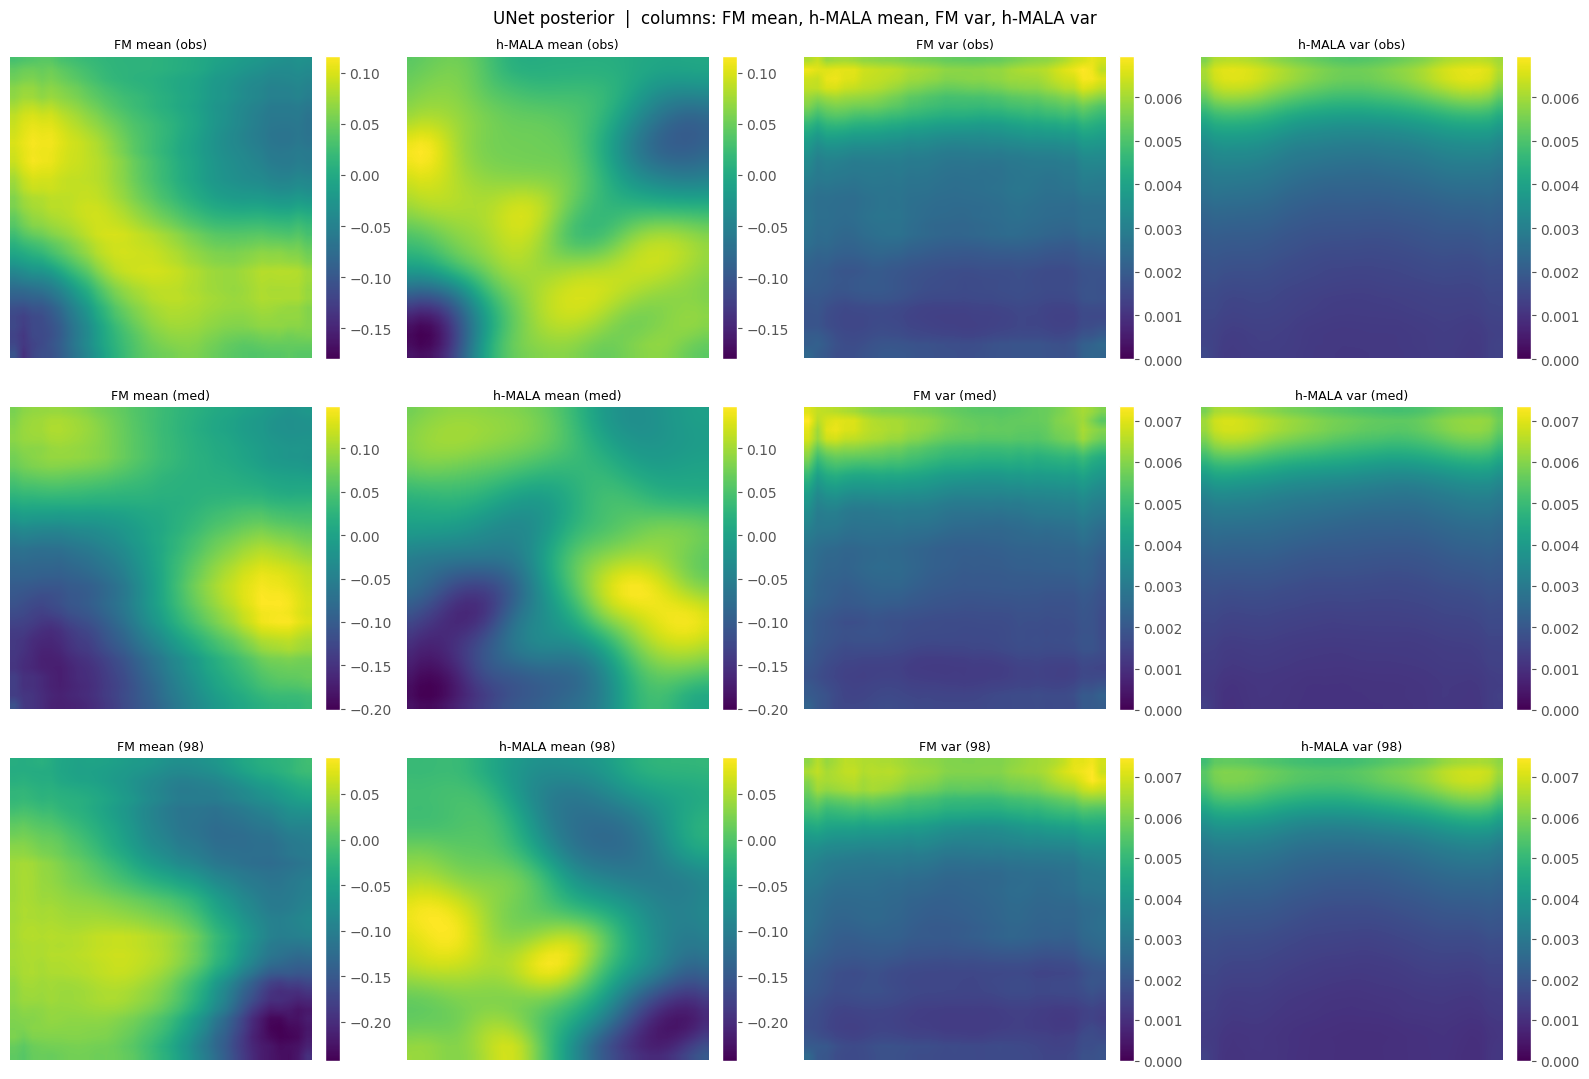

In [47]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle("UNet posterior  |  columns: FM mean, h-MALA mean, FM var, h-MALA var", fontsize=12)

for row, (label, u_grid, h_flat) in enumerate(zip(COND_LABELS, u_grid_list, hmala_list)):
    fm_mean = np.mean(u_grid, axis=0)
    fm_var  = np.var(u_grid,  axis=0)
    h_grid  = h_flat.reshape(-1, NX, NY)
    h_mean  = np.mean(h_grid, axis=0)
    h_var   = np.var(h_grid,  axis=0)

    vmin_m, vmax_m = min(fm_mean.min(), h_mean.min()), max(fm_mean.max(), h_mean.max())
    vmin_v, vmax_v = 0.0, max(fm_var.max(), h_var.max())

    for ax, arr, title, vmin, vmax in [
        (axes[row, 0], fm_mean, f"FM mean ({label})",      vmin_m, vmax_m),
        (axes[row, 1], h_mean,  f"h-MALA mean ({label})", vmin_m, vmax_m),
        (axes[row, 2], fm_var,  f"FM var ({label})",       vmin_v, vmax_v),
        (axes[row, 3], h_var,   f"h-MALA var ({label})",  vmin_v, vmax_v),
    ]:
        im = ax.imshow(arr, origin="lower", interpolation="bilinear", vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Individual sample comparison — main observation

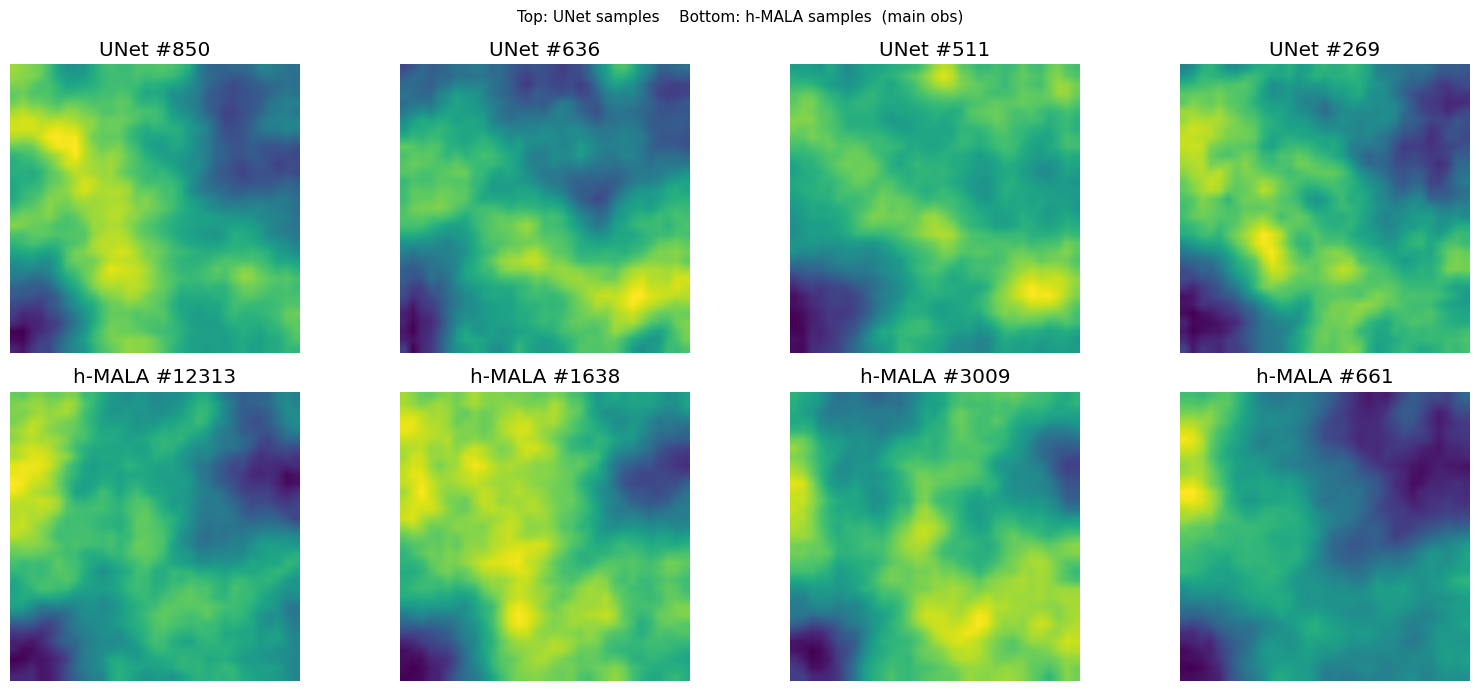

In [48]:
rng = np.random.default_rng(0)
fm_idx = rng.integers(0, 1000, 4)
hm_idx = rng.integers(0, hmala_obs.shape[0], 4)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Top: UNet samples    Bottom: h-MALA samples  (main obs)", fontsize=11)

u_grid_obs  = u_grid_list[0]
h_grid_obs  = hmala_obs.reshape(-1, NX, NY)

for j in range(4):
    ax = axes[0, j]
    ax.imshow(u_grid_obs[fm_idx[j]], origin="lower", interpolation="bilinear")
    ax.set_title(f"UNet #{fm_idx[j]}")
    ax.axis("off")

    ax = axes[1, j]
    ax.imshow(h_grid_obs[hm_idx[j]], origin="lower", interpolation="bilinear")
    ax.set_title(f"h-MALA #{hm_idx[j]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Variance scatter — FM vs h-MALA (main obs)

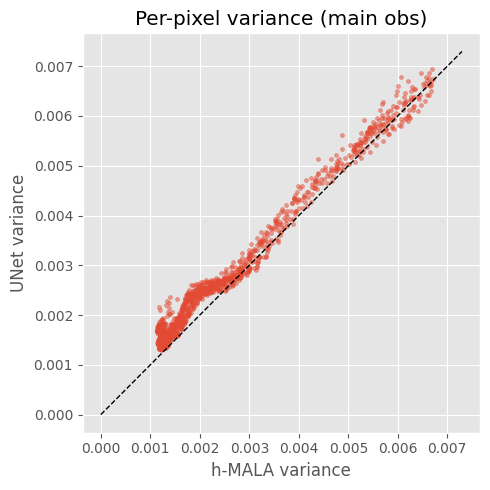

In [49]:
fm_var_obs = np.var(u_grid_list[0], axis=0).flatten()
hm_var_obs = np.var(hmala_obs.reshape(-1, NX, NY), axis=0).flatten()

plt.style.use("ggplot")
plt.figure(figsize=(5, 5))
plt.scatter(hm_var_obs, fm_var_obs, s=8, alpha=0.5)
lim = max(hm_var_obs.max(), fm_var_obs.max()) * 1.05
plt.plot([0, lim], [0, lim], "k--", lw=1)
plt.xlabel("h-MALA variance")
plt.ylabel("UNet variance")
plt.title("Per-pixel variance (main obs)")
plt.tight_layout()
plt.show()

## Sliced Wasserstein Distance

In [50]:
N_PROJ = 2048

# Base SWD: prior samples vs h-MALA (what the flow has to beat)
rng_b    = np.random.default_rng(42)
ref_idx  = rng_b.choice(len(us_ref), size=NSAMPLES, replace=False)
us_ref_s = us_ref[ref_idx]

print("Computing SWDs ...")
for label, u_flat, h_flat in zip(COND_LABELS, u_flat_list, hmala_list):
    base_swd = sliced_wasserstein_jax(
        jnp.asarray(us_ref_s), jnp.asarray(h_flat[:NSAMPLES]),
        n_projections=N_PROJ, seed=42,
    )
    unet_swd = sliced_wasserstein_jax(
        jnp.asarray(u_flat[:NSAMPLES]), jnp.asarray(h_flat[:NSAMPLES]),
        n_projections=N_PROJ, seed=42,
    )
    print(f"  [{label}]  base (prior vs MCMC) = {base_swd:.5f}  "
          f"UNet vs MCMC = {unet_swd:.5f}  "
          f"rel = {unet_swd/base_swd:.3f}")

Computing SWDs ...
  [obs]  base (prior vs MCMC) = 0.07999  UNet vs MCMC = 0.01899  rel = 0.237
  [med]  base (prior vs MCMC) = 0.09555  UNet vs MCMC = 0.01797  rel = 0.188
  [98]  base (prior vs MCMC) = 0.09426  UNet vs MCMC = 0.02066  rel = 0.219
